# Plots to assess the sensitivity of growth rates and trace element concentrations to peakID choices

*by Niels J. de Winter* - VU Amsterdam (n.j.de.winter@vu.nl)

In [6]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [5]:
element_summary_df = pd.read_csv("element_summary_by_peak_and_interval_peakID.csv") # Load element summary data
growth_intervals_df = pd.read_csv('Growth_intervals_summary_peakID.csv') # Load growth intervals data

print(element_summary_df.head())
print(growth_intervals_df.head())

  specimen    peakID category    element           mean           std  \
0     B255  peakID_1   peak 7       Ca43  416098.466128  46291.475506   
1     B255  peakID_1   peak 7  23Na/43Ca      22.945457      3.844426   
2     B255  peakID_1   peak 7  25Mg/43Ca       0.913142      0.191774   
3     B255  peakID_1   peak 7  43Ca/43Ca    1000.000000      0.000000   
4     B255  peakID_1   peak 7  55Mn/43Ca       0.004705      0.000695   

            se         cl95    N  growth_rate           start_date  \
0  3032.655393  5975.064833  233          NaN  2022-09-09 01:40:00   
1     0.251857     0.496219  233          NaN  2022-09-09 01:40:00   
2     0.012564     0.024753  233          NaN  2022-09-09 01:40:00   
3     0.000000     0.000000  233          NaN  2022-09-09 01:40:00   
4     0.000046     0.000090  233          NaN  2022-09-09 01:40:00   

              end_date  
0  2022-09-09 01:40:00  
1  2022-09-09 01:40:00  
2  2022-09-09 01:40:00  
3  2022-09-09 01:40:00  
4  2022-09-09 0

## Plot distribution of mean growth rates per interval per peakID

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
C:\Users\nwi213\AppData\Local\Temp\ipykernel_41952\656466237.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Growth Rate ($\mu$m/day)')


([<matplotlib.axis.XTick at 0x15ac36063f0>,
 [Text(0, 0, 'Interval 0'),
  Text(1, 0, 'Interval 1'),
  Text(2, 0, 'Interval 2'),
  Text(3, 0, 'Interval 3'),
  Text(4, 0, 'Interval 4'),
  Text(5, 0, 'Interval 5'),
  Text(6, 0, 'Interval 6'),
  Text(7, 0, 'Interval 7')])

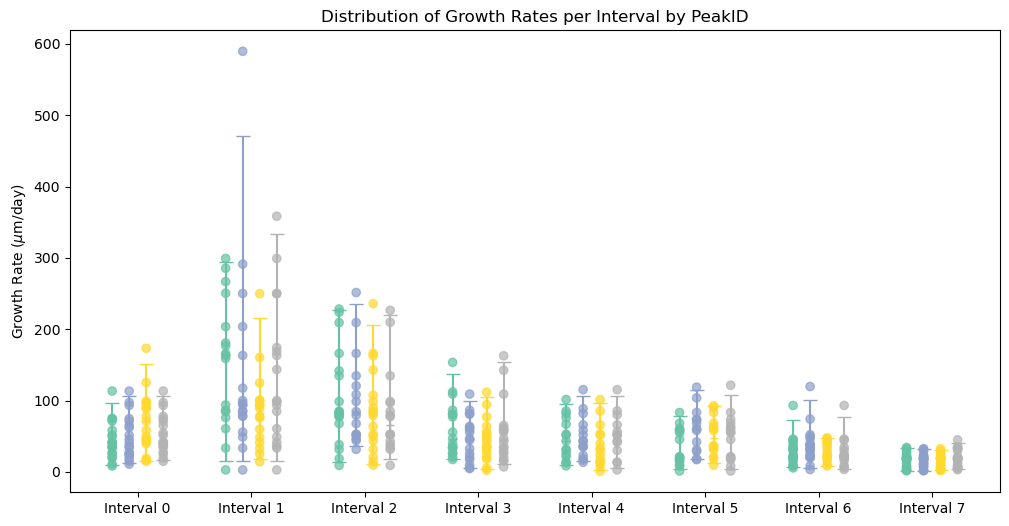

In [ ]:
# Plot distribution of growth rates among specimens per interval colored by peakID
plt.figure(figsize=(12, 6))
# Convert peakID to numeric codes for coloring
growth_intervals_df['peakid_codes'] = growth_intervals_df['peakID'].astype('category').cat.codes % 4 + 1  # Ensure codes are 1, 2, 3, 4
# Add a small offset to the x positions based on peakID to separate categories
offsets = (growth_intervals_df['peakid_codes'] - 2.5) * 0.15  # Adjust 0.15 for desired separation
# extract trailing number from 'Interval' (handles multi-digit intervals) and convert to int
growth_intervals_df['Interval_number'] = growth_intervals_df['Interval'].str.extract(r'(\d+)$')[0].astype(int) # Extract trailing number
growth_intervals_df['x_values'] = growth_intervals_df['Interval_number'] + offsets # Apply offsets to x values

# Calculate medians and 95% confidence intervals for each interval and peakID
median_growth = growth_intervals_df.groupby(['Interval_number', 'peakid_codes'])['growth_rate'].median()
ci_lower = growth_intervals_df.groupby(['Interval_number', 'peakid_codes'])['growth_rate'].quantile(0.025)
ci_upper = growth_intervals_df.groupby(['Interval_number', 'peakid_codes'])['growth_rate'].quantile(0.975)

# Scatter plot
scatter = plt.scatter(growth_intervals_df['x_values'], 
                      growth_intervals_df['growth_rate'], 
                      c=growth_intervals_df['peakid_codes'], cmap='Set2', alpha=0.7)

# Plot medians and confidence intervals
cmap = plt.get_cmap('Set2')
for (interval, peakid), median in median_growth.items():
    color = cmap((peakid - 1) / 3)  # Normalize peakid to [0, 1] for 4 categories
    plt.errorbar(interval + (peakid - 2.5) * 0.15, median, 
                 yerr=[[median - ci_lower[interval, peakid]], [ci_upper[interval, peakid] - median]], 
                 fmt='+', color=color, capsize=5)

# Customize plot
plt.title('Distribution of Growth Rates per Interval by PeakID')
plt.ylabel('Growth Rate ($\mu$m/day)')
plt.xticks(ticks=range(0, growth_intervals_df['Interval_number'].max() + 1), 
           labels=[f'Interval {i}' for i in range(0, growth_intervals_df['Interval_number'].max() + 1)]
)

## Plot distribution of mean trace element concentrations per interval per peakID

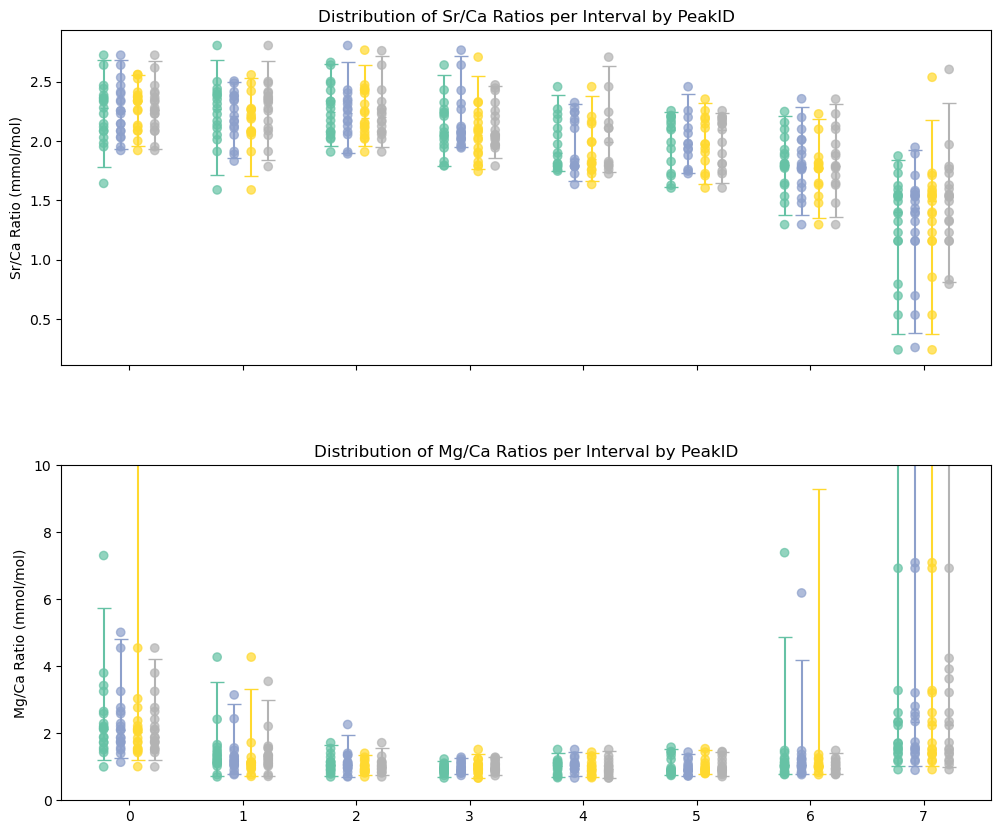

In [79]:
# Create figure
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(hspace=0.3)  # Add space between subplots
top_ax, bottom_ax = axs

# Filter element_summary_df for Sr/Ca data
sr_data = element_summary_df[element_summary_df['element'] == '88Sr/43Ca'].copy()
mg_data = element_summary_df[element_summary_df['element'] == '25Mg/43Ca'].copy()

mg_data.head()

# Extract interval number from category
sr_data['Interval_number'] = sr_data['category'].str.extract(r'interval (\d+)').astype(float)
mg_data['Interval_number'] = mg_data['category'].str.extract(r'interval (\d+)').astype(float)

# Convert peakID to numeric codes for coloring (same as before)
sr_data['peakid_codes'] = sr_data['peakID'].str.extract(r'(\d+)$').astype(int)
mg_data['peakid_codes'] = mg_data['peakID'].str.extract(r'(\d+)$').astype(int)

# Calculate x-values with offset
sr_data['x_values'] = sr_data['Interval_number'] + (sr_data['peakid_codes'] - 2.5) * 0.15
mg_data['x_values'] = mg_data['Interval_number'] + (mg_data['peakid_codes'] - 2.5) * 0.15

# Calculate statistics per interval and peakID
median_sr = sr_data.groupby(['Interval_number', 'peakid_codes'])['mean'].median()
median_mg = mg_data.groupby(['Interval_number', 'peakid_codes'])['mean'].median()
sr_ci_lower = sr_data.groupby(['Interval_number', 'peakid_codes'])['mean'].quantile(0.025)
mg_ci_lower = mg_data.groupby(['Interval_number', 'peakid_codes'])['mean'].quantile(0.025)
sr_ci_upper = sr_data.groupby(['Interval_number', 'peakid_codes'])['mean'].quantile(0.975)
mg_ci_upper = mg_data.groupby(['Interval_number', 'peakid_codes'])['mean'].quantile(0.975)

# Create scatter plots
sr_scatter = top_ax.scatter(sr_data['x_values'], 
                     sr_data['mean'], 
                     c=sr_data['peakid_codes'], 
                     cmap='Set2', 
                     alpha=0.7)
mg_scatter = bottom_ax.scatter(mg_data['x_values'], 
                     mg_data['mean'], 
                     c=mg_data['peakid_codes'], 
                     cmap='Set2', 
                     alpha=0.7)

# Plot medians and confidence intervals
cmap = plt.get_cmap('Set2')
for (interval, peakid), median in median_sr.items():
    color = cmap((peakid - 1) / 3)
    top_ax.errorbar(interval + (peakid - 2.5) * 0.15, median,
                 yerr=[[median - sr_ci_lower[interval, peakid]], [sr_ci_upper[interval, peakid] - median]],
                 fmt='+', color=color, capsize=5)
for (interval, peakid), median in median_mg.items():
    color = cmap((peakid - 1) / 3)
    bottom_ax.errorbar(interval + (peakid - 2.5) * 0.15, median,
                 yerr=[[median - mg_ci_lower[interval, peakid]], [mg_ci_upper[interval, peakid] - median]],
                 fmt='+', color=color, capsize=5)

# Customize plot (use Axes methods)
top_ax.set_title('Distribution of Sr/Ca Ratios per Interval by PeakID')
top_ax.set_ylabel('Sr/Ca Ratio (mmol/mol)')
bottom_ax.set_title('Distribution of Mg/Ca Ratios per Interval by PeakID')
bottom_ax.set_ylabel('Mg/Ca Ratio (mmol/mol)')
bottom_ax.set_ylim(0, 10)  # Set y-axis limit to start at 0

plt.show()